# Resumo do projeto e objetivos

O objetivo deste projeto é desenvolver e analisar uma pipeline completa de processamento de sinais de ECG, utilizando técnicas de Processamento Digital de Sinais. 

Especificamente, busca-se investigar a remoção de ruído por meio de filtragem FIR, analisando a equivalência entre a convolução discreta no domínio do tempo e sua implementação eficiente via FFT, e explorar a extração de padrões locais utilizando filtros de Gabor 1D. 

Adicionalmente, pretende-se realizar a análise do conteúdo espectral do sinal por meio de representações tempo-frequência, como o espectrograma. Por fim, as características extraídas serão empregadas em uma tarefa de classificação de batimentos cardíacos, permitindo avaliar quantitativamente o desempenho do projeto desenvolvido.

In [ ]:
import wfdb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import firwin, filtfilt, convolve, fftconvolve, butter, cheby1, ellip, iirnotch

# Descrição da base de dados; 

O MIT-BIH Arrhythmia Database, desenvolvido entre 1975 e 1980 em uma colaboração entre o MIT e o Beth Israel Hospital de Boston. A base consiste em 48 registros de ECG de dois canais, cada um com 30 minutos de duração, totalizando cerca de 110.000 batimentos cardíacos meticulosamente anotados por especialistas. Os dados, provenientes de 47 sujeitos, incluem tanto amostras aleatórias quanto casos de arritmias raras e clinicamente significativas, digitalizados a uma frequência de 360 Hz com resolução de 11 bits.

Resumo geral:
- Quantidade de registros: 48
- Amostragem: 360Hz 
- Quantização: 11 bits

Para cada registro, há 3 tipos de arquivos.

- .dat: Os arquivos contendo os dados.
- .hea: Os cabeçalhos, indicando frequência e outras informações.
- .atr: Anotações dos médicos, indicando informações importantes.

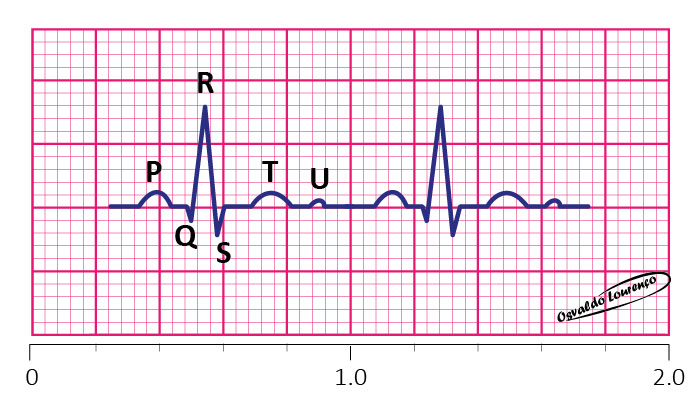

- Onda P: Representa a despolarização atrial, ou seja, a contração dos átrios.
- Complexo QRS: Representa a despolarização ventricular, ou seja, a contração dos ventrículos. É a onda mais proeminente e indica a atividade elétrica mais forte do coração.
- Onda T: Representa a repolarização ventricular, ou seja, o relaxamento dos ventrículos após a contração. Este é um processo crucial para preparar o coração para o próximo batimento.

In [ ]:
drive_path = "./PSD-Trabalho"

if not os.path.exists(drive_path):
    os.makedirs(drive_path)
    print(f"Pasta criada em: {drive_path}")
else:
    print(f"A pasta já existe em: {drive_path}")

In [ ]:
records = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '230', '231', '232', '233', '234'
]

# Analise Exploratória de Dados

## Anotações dos Médicos

Para simplificar a avaliação de algoritmos e a análise clínica, a norma AAMI (Association for the Advancement of Medical Instrumentation) recomenda agrupar as dezenas de símbolos detalhados do MIT-BIH em cinco categorias fundamentais. Esse agrupamento organiza os batimentos conforme sua origem fisiológica e impacto clínico, permitindo que pesquisadores foquem nas patologias principais em vez de se perderem em subdivisões técnicas excessivas.

- N (Normal): Agrupa os batimentos normais e os bloqueios de ramo (símbolos N, L, R, e, j).
- S (Supraventricular): Agrupa batimentos prematuros que nascem acima dos ventrículos (símbolos A, a, J, S).
- V (Ventricular): Focado em arritmias ventriculares perigosas, como contrações prematuras e escapes (símbolos V, E).
- F (Fusão): Representa batimentos que são uma mistura de um ritmo normal com um ventricular (símbolo F).
- Q (Desconhecido/Outros): Inclui batimentos de marca-passo, batimentos que não puderam ser classificados ou artefatos graves (símbolos /, f, Q).


In [ ]:
wfdb.show_ann_labels()

## Tipos de Derivações do ECG

As derivações de ECG funcionam como "câmeras" posicionadas em ângulos distintos para capturar a atividade elétrica do coração. No MIT-BIH, cada registro utiliza apenas duas dessas visões simultâneas.
As derivações presentes no banco de dados são:

- MLII: A mais comum; ideal para monitorar o ritmo e identificar picos do batimento.
- V1: Focada no lado direito e septo.
- V2: Observa a parede anterior do coração e a transição entre os ventrículos.
- V4: Posicionada no ápice cardíaco para avaliar a força da contração ventricular.
- V5: Focada no ventrículo esquerdo, principal escolha para arritmias ventriculares graves.


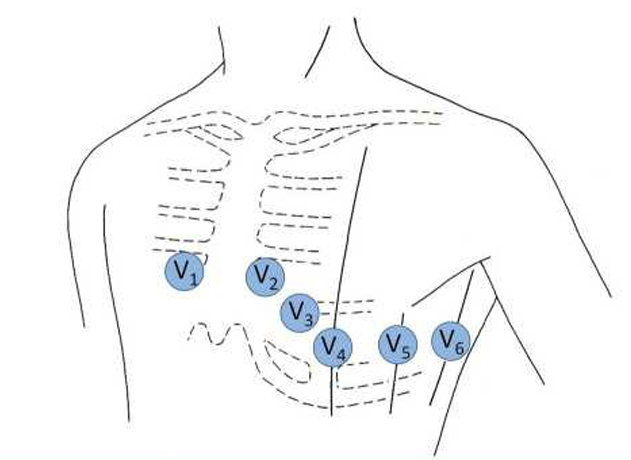

In [ ]:
def analisar_canais(diretorio):
    todos_os_canais = []

    for r in records:
        path = os.path.join(diretorio, r)
        try:
            header = wfdb.rdheader(path)
            todos_os_canais.extend(header.sig_name)
        except Exception as e:
            print(f"Erro ao ler cabeçalho {r}: {e}")

    df_contagem = pd.Series(todos_os_canais).value_counts().reset_index()
    df_contagem.columns = ['Derivação', 'Quantidade de Registros']

    df_contagem['Porcentagem (%)'] = (df_contagem['Quantidade de Registros'] / len(records)) * 100

    return df_contagem

resultado = analisar_canais(drive_path)

print("--- Distribuição de Canais no MIT-BIH ---")
print(resultado.to_string(index=False))

## Plot Sinal Original

In [ ]:
record_name = '201' 
path = os.path.join(drive_path, record_name)

record = wfdb.rdrecord(path, sampto=1500)
ann = wfdb.rdann(path, 'atr', sampto=1500)

wfdb.plot_wfdb(record=record, annotation=ann, title=f'Registro {record_name} - MIT-BIH')

In [ ]:
record_name = '102' 
path = os.path.join(drive_path, record_name)

record = wfdb.rdrecord(path, sampto=1500)
ann = wfdb.rdann(path, 'atr', sampto=1500)

signal = record.p_signal[:, 0] 
tempo = np.arange(len(signal)) / record.fs 

plt.figure(figsize=(15, 6))
plt.plot(tempo, signal, color='blue', label='Sinal de ECG', lw=1)

for i in range(len(ann.sample)):
    idx = ann.sample[i]       
    simbolo = ann.symbol[i]   
    
    plt.text(tempo[idx], signal[idx] + 0.1, simbolo, 
             fontsize=12, fontweight='bold', color='red', ha='center')

plt.title(f"Visualização Detalhada - Registro {record_name}")
plt.xlabel("Tempo (segundos)")
plt.ylabel("Voltagem (mV)")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
record_name = '104' 
path = os.path.join(drive_path, record_name)
ann = wfdb.rdann(path, 'atr')

indices_q = [i for i, simbolo in enumerate(ann.symbol) if simbolo == 'Q']

if len(indices_q) == 0:
    print(f"Nenhuma anotação 'Q' encontrada no registro {record_name}.")
else:
    idx_primeiro_q = indices_q[0]
    ponto_central = ann.sample[idx_primeiro_q]
    
    fs = wfdb.rdheader(path).fs
    
    janela_segundos = 3
    sampfrom = max(0, ponto_central - (janela_segundos * fs))
    sampto = ponto_central + (janela_segundos * fs)
    
    record = wfdb.rdrecord(path, sampfrom=sampfrom, sampto=sampto)
    ann = wfdb.rdann(path, 'atr', sampfrom=sampfrom, sampto=sampto)
    
    signal = record.p_signal[:, 0] 
    tempo = (np.arange(len(signal)) + sampfrom) / fs 

    plt.figure(figsize=(15, 6))
    plt.plot(tempo, signal, color='blue', label='Sinal de ECG', lw=1)

    for i in range(len(ann.sample)):
        idx_relativo = ann.sample[i] - sampfrom       
        simbolo = ann.symbol[i]   
        
        if simbolo == 'Q':
            cor = 'magenta'
            tamanho = 16
        else:
            cor = 'red'
            tamanho = 12

        if 0 <= idx_relativo < len(signal):
            plt.text(tempo[idx_relativo], signal[idx_relativo] + 0.1, simbolo, 
                     fontsize=tamanho, fontweight='bold', color=cor, ha='center')

    plt.title(f"Visualização Detalhada - Registro {record_name} (Focado no batimento 'Q')")
    plt.xlabel("Tempo Absoluto (segundos)")
    plt.ylabel("Voltagem (mV)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show() 

## Análise das Médias e conversão para Pandas

In [ ]:
def analisar_base_completa(diretorio):
    consolidado = []

    print(f"Iniciando leitura de {len(records)} registros...")

    for r in records:
        path = os.path.join(diretorio, r)
        
        try:
            record = wfdb.rdrecord(path)
            signal = record.p_signal[:, 0] 
            fs = record.fs
            
            ann = wfdb.rdann(path, 'atr')
            
            v_mean = np.mean(signal)
            v_std = np.std(signal)
            v_max = np.max(signal)
            v_min = np.min(signal)
            
            rr_intervals = np.diff(ann.sample) / fs
            hr = 60 / rr_intervals
            hr = hr[(hr > 30) & (hr < 200)] 
            
            beat_counts = pd.Series(ann.symbol).value_counts().to_dict()
            
            resumo_registro = {
                'record': r,
                'fs': fs,
                'n_samples': len(signal),
                'mean_volt': v_mean,
                'std_volt': v_std,
                'max_volt': v_max,
                'min_volt': v_min,
                'mean_hr': np.mean(hr) if len(hr) > 0 else 0,
                'std_hr': np.std(hr) if len(hr) > 0 else 0,
                'total_beats': len(ann.sample),
                **beat_counts # Adiciona as contagens de 'N', 'V', 'A', etc.
            }
            
            consolidado.append(resumo_registro)

        except Exception as e:
            print(f"Erro ao processar registro {r}: {e}")

    df = pd.DataFrame(consolidado)
    
    df = df.fillna(0)
    
    return df

# Executar a função
df_eda = analisar_base_completa(drive_path)

In [ ]:
print("\n--- Primeiras linhas do DataFrame de EDA ---")
print(df_eda.head())

In [ ]:
print("\n--- Estatísticas Globais da Frequência Cardíaca ---")
print(df_eda['mean_hr'].describe())

In [ ]:
df_eda.set_index('record')[['N', 'V', 'L', 'R', 'A']].plot(kind='bar', stacked=True)

In [ ]:
def ver_detalhes_registro(df, registro):
    dados_registro = df[df['record'] == str(registro)]
    
    if dados_registro.empty:
        print(f"Registro {registro} não encontrado no DataFrame.")
        return

    metadados = [
        'record', 'fs', 'n_samples', 'mean_volt', 'std_volt', 
        'max_volt', 'min_volt', 'mean_hr', 'std_hr', 'total_beats'
    ]
    
    distribuicao = dados_registro.drop(columns=metadados).iloc[0]
    distribuicao = distribuicao[distribuicao > 0].sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    ax = distribuicao.plot(kind='bar', color='skyblue', edgecolor='black')
    
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    plt.title(f"Distribuição Completa de Símbolos - Registro {registro}")
    plt.ylabel("Quantidade de Batimentos")
    plt.xlabel("Símbolos (Anotações)")
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    df_temp = pd.DataFrame({
        'Quantidade': distribuicao.values,
        'Porcentagem (%)': (distribuicao.values / dados_registro['total_beats'].values[0] * 100).round(2)
    }, index=distribuicao.index)
    
    print(f"\nTabela de composição do Registro {registro}:")
    print(df_temp)

ver_detalhes_registro(df_eda, '232')

In [ ]:
def ver_distribuicao_global(df):
    metadados = [
        'record', 'fs', 'n_samples', 'mean_volt', 'std_volt', 
        'max_volt', 'min_volt', 'mean_hr', 'std_hr', 'total_beats'
    ]
    
    distribuicao_global = df.drop(columns=metadados).sum().sort_values(ascending=False)
    
    distribuicao_global = distribuicao_global[distribuicao_global > 0]

    total_geral_batimentos = df['total_beats'].sum()

    plt.figure(figsize=(15, 7))
    ax = distribuicao_global.plot(kind='bar', color='salmon', edgecolor='black', log=True)
    
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2., p.get_height()), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.title("Distribuição Global de Todos os Batimentos (MIT-BIH Database)")
    plt.ylabel("Quantidade Total (Escala Logarítmica)")
    plt.xlabel("Símbolos (Anotações)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    df_resumo = pd.DataFrame({
        'Total Acumulado': distribuicao_global.values.astype(int),
        'Porcentagem Global (%)': (distribuicao_global.values / total_geral_batimentos * 100).round(4)
    }, index=distribuicao_global.index)
    
    print("--- ESTATÍSTICAS GLOBAIS DO DATASET ---")
    print(f"Total de Batimentos Processados: {int(total_geral_batimentos)}")
    print(df_resumo)

ver_distribuicao_global(df_eda)

In [ ]:
n_amostras = 1500
metade = n_amostras // 2
fs = 360

soma_magnitudes = np.zeros(metade)
contador_sucesso = 0


for record_name in records:
    path = os.path.join(drive_path, record_name)
    try:
        record = wfdb.rdrecord(path, sampto=n_amostras)
        sinal = record.p_signal[:, 0]
        
        fft_values = np.fft.fft(sinal)
        magnitude = np.abs(fft_values[:metade])
        
        magnitude_norm = magnitude / np.max(magnitude)
        
        soma_magnitudes += magnitude_norm
        contador_sucesso += 1
        
    except Exception as e:
        print(f"ERRO {record_name}")

media_magnitude = soma_magnitudes / contador_sucesso

freqs = np.fft.fftfreq(n_amostras, 1/fs)[:metade]

plt.figure(figsize=(12, 6))
plt.plot(freqs, media_magnitude, color='red', linewidth=2)

plt.title(f'Espectro Médio de Frequência (Soma de {contador_sucesso} registros)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude Média Normalizada')
plt.grid(True)

#Usar aqui para definir janela, caso seja necessário análise mais especifica de alguma faixa
plt.xlim(1, 100)
plt.ylim(0,0.2)

plt.show()

## Resumo dos Tipos de Artefatos e Ruídos Esperados

### Baseline Wander (Deriva de Linha de Base)
* **Causas:** Respiração, movimentação do paciente e mudanças de impedância eletrodo-pele.
* **Características:** Frequências muito baixas (geralmente abaixo de 0,5 Hz).
* **Efeito no ECG:** Desloca gradualmente a linha de base do traçado, prejudicando a medição de amplitudes e a interpretação do segmento ST e de ondas pequenas.

### Interferência da Rede Elétrica
* **Causas:** Acoplamento com a rede de energia elétrica do ambiente.
* **Características:** Onda senoidal concentrada em 50 ou 60 Hz, podendo incluir harmônicos.
* **Tratamento:** Pode ser atenuada de forma eficaz utilizando filtros rejeita-faixa (notch) estreitos.

### Ruído Muscular (EMG)
* **Causas:** Atividade dos músculos esqueléticos durante o exame.
* **Características:** Ruído de banda larga, concentrado em frequências mais altas que o ECG, geralmente com comportamento não estacionário.
* **Efeito no ECG:** Pode mascarar as bordas do complexo QRS e prejudicar análises de tempo-frequência.

### Artefatos de Movimento
* **Causas:** Movimentos abruptos do paciente e falhas de contato entre o eletrodo e a pele.
* **Características:** Geração de ruídos imprevisíveis, como transientes abruptos ou distorções locais de grande amplitude.
* **Desafio:** Por serem irregulares, dificilmente são removidos por completo com apenas uma única etapa de filtragem linear.

# Estratégias e Técnicas

## FIR Filter

- Aplicar um filtro FIR é realizar uma convolução entre o sinal e uma resposta ao impulso finita para remover ruídos, preservando a morfologia do sinal original.
- Em ECG, a morfologia do sinal é essencial para identificar corretamente eventos cardíacos

## FIR com Método da Janela

In [ ]:
def fir_bandpass(signal, fs, low=0.5, high=40, numtaps=100):
    nyq = fs / 2
    taps = firwin(numtaps, [low/nyq, high/nyq], pass_zero=False)
    filtered = filtfilt(taps, [1.0], signal)
    return filtered, taps

record_name = '201' 
path = os.path.join("./PSD-Trabalho", record_name)
record = wfdb.rdrecord(path, sampto=n_amostras)
signal = record.p_signal[:, 0]

signal_fir, taps = fir_bandpass(signal, fs)

plt.figure(figsize=(15,5))
plt.plot(tempo[:fs*2], signal_fir[:fs*2])

plt.title("ECG após Filtro FIR")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.show()

In [ ]:
n = len(signal)
freqs = np.fft.fftfreq(n, 1/fs)[:n//2]

fft_raw = np.abs(np.fft.fft(signal)[:n//2])
fft_filtered = np.abs(np.fft.fft(signal_fir)[:n//2])

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
tempo = np.arange(n) / fs
plt.plot(tempo, signal, label='Original (Bruto)', alpha=0.7)
plt.plot(tempo, signal_fir, label='Filtrado (0.5-40Hz)', linewidth=1.5)
plt.title(f"Comparação no Domínio do Tempo - Registro {record_name}")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freqs, fft_raw, label='Espectro Original', alpha=0.5, color='gray')
plt.plot(freqs, fft_filtered, label='Espectro Filtrado', color='red')

plt.axvline(x=0.5, color='blue', linestyle='--', alpha=0.5, label='Corte Inferior (0.5Hz)')
plt.axvline(x=40, color='green', linestyle='--', alpha=0.5, label='Corte Superior (40Hz)')

plt.title("Comparação no Domínio da Frequência (FFT)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 100) 
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## IIR Filter
- O filtro IIR, não possui fase linear e pode introduzir distorções de fase no sinal, diferentemente dos filtros FIR, que podem ser projetados para manter fase linear.

In [ ]:

def bandpass_butter(signal, fs, low=0.5, high=40, order=4):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

def bandpass_cheby(signal, fs, low=0.5, high=40, order=4, ripple=1):
    nyq = fs / 2
    b, a = cheby1(order, ripple, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

def bandpass_ellip(signal, fs, low=0.5, high=40, order=4, ripple=1, stop_atten=40):
    nyq = fs / 2
    b, a = ellip(order, ripple, stop_atten, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)


record = wfdb.rdrecord(path, sampto=n_amostras)
signal = record.p_signal[:, 0]

signal_fir = fir_bandpass(signal, fs)
signal_butter = bandpass_butter(signal, fs)
signal_cheby = bandpass_cheby(signal, fs)
signal_ellip = bandpass_ellip(signal, fs)

plt.figure(figsize=(15, 12))

plt.subplot(4, 1, 1)
plt.plot(tempo[:fs*2], signal_fir[:fs*2])
plt.title("FIR (Referência)")
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(tempo[:fs*2], signal_butter[:fs*2])
plt.title("IIR - Butterworth")
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(tempo[:fs*2], signal_cheby[:fs*2])
plt.title("IIR - Chebyshev")
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(tempo[:fs*2], signal_ellip[:fs*2])
plt.title("IIR - Elíptico")
plt.grid()

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

plt.plot(tempo[:fs*2], signal_fir[:fs*2], label='FIR', linewidth=2)
plt.plot(tempo[:fs*2], signal_butter[:fs*2], label='Butterworth', alpha=0.7)
plt.plot(tempo[:fs*2], signal_cheby[:fs*2], label='Chebyshev', alpha=0.7)
plt.plot(tempo[:fs*2], signal_ellip[:fs*2], label='Elíptico', alpha=0.7)

plt.legend()
plt.title("Comparação: FIR vs IIR")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.show()

## Convolução Temporal

### Notch Filter

- O notch filter é um filtro faixa que remove uma frequência específica ou uma faixa muito estreita de frequências.
- Neste caso, utilizado para eliminar interferências fixas, como ruído de rede elétrica (60 Hz).

In [ ]:
record_name = '201' 
path = os.path.join("./PSD-Trabalho", record_name)
record = wfdb.rdrecord(path, sampto=1500) 
signal_data = record.p_signal[:, 0]

b, a = iirnotch(60.0, 30, fs)

signal_notch = filtfilt(b, a, signal_data)

tempo = np.arange(len(signal_data)) / fs

plt.figure(figsize=(15,5))
plt.plot(tempo[:fs*2], signal_notch[:fs*2])

plt.title("ECG após Filtro Notch")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()
plt.show()

In [ ]:
n = len(signal)
freqs = np.fft.fftfreq(n, 1/fs) 

fft_original = np.abs(np.fft.fft(signal))
fft_filtered = np.abs(np.fft.fft(signal_notch))

half_n = n // 2
freqs_half = freqs[:half_n]
fft_original_half = fft_original[:half_n]
fft_filtered_half = fft_filtered[:half_n]

plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(freqs_half, fft_original_half, color='red', alpha=0.7)
plt.title("Espectro de Frequência (Original)")
plt.ylabel("Magnitude")
plt.grid()
plt.ylim(0,80)
plt.xlim(1, 100) 

plt.subplot(2, 1, 2)
plt.plot(freqs_half, fft_filtered_half, color='blue')
plt.title("Espectro de Frequência (Após Notch 60Hz)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.ylim(0,80)
plt.xlim(1, 100) 
plt.tight_layout()
plt.show()

### Filtro de Média

- Suavização de Sinal

### Filtro passa Alta

- Eliminar Baseline Wonder (Frequência extremamente baixa)

## Convolução Rápida (Domínio da Frequência)

- A convolução rápida utiliza a Transformada Rápida de Fourier (FFT) para realizar a filtragem no domínio da frequência.
- Em seguida, aplica-se a Transformada Inversa de Fourier (IFFT) para retornar ao domínio do tempo.

In [ ]:
def apply_fast_convolution(signal, taps):
    n = len(signal)
    X_omega = np.fft.fft(signal, n=n)
    H_omega = np.fft.fft(taps, n=n)
    
    Y_omega = X_omega * H_omega
    
    filtered = np.fft.ifft(Y_omega).real
    return filtered

signal_convolved = apply_fast_convolution(signal, taps)

plt.figure(figsize=(15, 5))
plt.plot(tempo[:fs*2], signal_convolved[:fs*2], label='Convolução Rápida (FFT)', color='purple')
plt.title("ECG após Convolução Rápida")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.legend()

## Extração de Características

A partir do ECG filtrado, construiremos vetores de características.

Inicialmente possuimos a seguintes ideias, baseando-se no material provido pelo professor:

* Amplitude máxima do batimento;
* Energia do sinal calculado em janelas específicas;
* Largura aproximada do complexo QRS.
* Média e desvio-padrão das respostas dos filtros de Gabor;
* Energia por escala ou por frequência central;
* Centroides espectrais;
* Largura de banda efetiva;
* Energia concentrada em bandas específicas do espectrograma;
* Posição temporal do pico máximo da resposta.

Obs: Iremos, claro, usar métodos para avaliar a influência dessas features no modelo, eventualmente acrescentando ou removendo.

Ao final, **pretendemos utilizar esse vetor de características como entrada para o treinamento de modelos de *machine learning par CLASSIFICAÇÃO***.

## Classificação

Modelos vão ser baseados após obter os resultados da extração

# Avaliação dos Resultados Esperados

A avaliação da eficácia do sistema deve ser conduzida de forma abrangente, considerando a convergência entre múltiplos indicadores quantitativos. Esses indicadores contemplam tanto o desempenho da etapa de filtragem quanto a qualidade da etapa de classificação, permitindo uma análise mais completa do comportamento do sistema.

## Erro Quadrático Médio entre as Saídas de Filtragem

A equivalência entre a convolução no domínio do tempo e a convolução realizada via FFT pode ser quantificada por meio do erro quadrático médio (MSE).
Essa métrica mede a discrepância média entre os sinais resultantes das duas abordagens.

![eqm.png](images/eqm.png)

Valores de MSE próximos de zero indicam que ambas as implementações produzem resultados numericamente equivalentes, conforme esperado pela teoria. Dessa forma, o MSE atua como um critério importante para validar a correta implementação dos métodos de filtragem.

## Relação Sinal-Ruído e Atenuação do Ruído

A eficácia da filtragem também pode ser avaliada por meio da relação sinal-ruído (SNR), que quantifica a proporção entre a potência do sinal útil e a potência do ruído presente.

A comparação do SNR antes e depois da filtragem permite medir o ganho obtido na remoção de ruído. No entanto, é importante destacar que um aumento no SNR não garante, por si só, a preservação adequada da morfologia do sinal.

![rar.png](images/rar.png)

Por esse motivo, a análise do SNR deve ser complementada por métricas estruturais. Nesse contexto, destaca-se o erro percentual da amplitude do pico R, que avalia o quanto a filtragem altera um dos componentes mais relevantes do ECG. 
Valores baixos dessa métrica indicam boa preservação morfológica, enquanto valores elevados sugerem distorções introduzidas pelo processo de filtragem.

![epa.png](images/epa.png)

onde "AR,referencia" representa a amplitude do pico R no sinal de referência, enquanto "Ar,filtrado", representa a amplitude do pico R após o processamento de fitlragem

Essa métrica é particularmente adequada, pois o pico R constitui, em geral, o componente mais robusto e mais relevante do ECG para tarefas de segmentação e análise automática. Valores reduzidos de ER indicam boa preservação da morfologia local mais significativa do traçado, enquanto valores elevados sugerem que a filtragem atenuou o ruído à custa da distorção de um elemento central do sinal.

## Energia e Concentração no Espectro de Potência Tempo-Frequência

A análise no domínio tempo-frequência, realizada por meio de espectrogramas, deve ser acompanhada por métricas que sintetizem a distribuição de energia do sinal.

Entre as principais medidas, destacam-se a energia total em bandas de frequência específicas, o centroide espectral, a largura de banda efetiva e a razão entre energia em faixas de interesse e energia total.

Essas métricas funcionam como descritores da organização espectral do ECG. Em geral, sinais mais regulares apresentam maior concentração de energia em regiões específicas, enquanto sinais ruidosos ou anômalos tendem a apresentar distribuição espectral mais dispersa.

## Acurácia, Precisão, Revocação e F1-Score

A Acurácia representa a proporção global de classificações corretas realizadas pelo modelo, considerando tanto os verdadeiros positivos quanto os verdadeiros negativos.

A Precisão mede a fração de previsões positivas que estão corretas.

A Revocação mede a fração dos positivos reais corretamente identificados.

A F1-Score combina ambas em uma média harmônica.

A utilização conjunta dessas métricas é essencial, pois permite diferenciar um classificador que identifica muitos casos positivos, porém com elevada taxa de falsos alarmes, de outro mais conservador, que tende a reduzir erros ao custo de menor sensibilidade.

## Matriz de Confusão e Robustez

A Matriz de confusão é uma ferramenta fundamental para analisar detalhadamente os erros de classificação, evidenciando quais classes são mais frequentemente confundidas entre si.

Além disso, a avaliação deve considerar a robustez do sistema frente a diferentes configurações. Isso inclui variações nos parâmetros do filtro FIR, nas configurações do banco de filtros de Gabor, nas janelas utilizadas na STFT e na divisão entre conjuntos de treino e teste.

Essa análise é essencial para garantir que o desempenho observado não seja resultado de uma configuração específica, mas sim uma característica consistente do sistema.